[orchestrator] 작업 3개 생성: ['작업-1', '작업-2', '작업-3']
  → 워커 3개 실행됨: ['작업-1 처리 완료', '작업-2 처리 완료', '작업-3 처리 완료']

[orchestrator] 작업 6개 생성: ['작업-1', '작업-2', '작업-3', '작업-4', '작업-5', '작업-6']
  → 워커 6개 실행됨: ['작업-1 처리 완료', '작업-2 처리 완료', '작업-3 처리 완료', '작업-4 처리 완료', '작업-5 처리 완료', '작업-6 처리 완료']

── 그래프 구조: worker 노드는 '하나'로 그려진다 ──


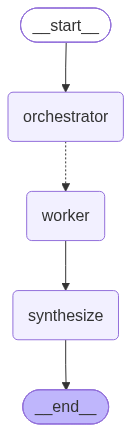

In [1]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

class OrchState(TypedDict):
    n: int
    tasks: list
    results: Annotated[list, operator.add]   # 워커들이 채운다 → 리듀서 필수

class WorkerInput(TypedDict):
    task: str                                # 워커 하나가 받는 '자기 몫'
    results: Annotated[list, operator.add]

def orchestrator(state: OrchState):
    tasks = [f"작업-{i+1}" for i in range(state["n"])]
    print(f"[orchestrator] 작업 {len(tasks)}개 생성: {tasks}")
    return {"tasks": tasks}

def worker(state: WorkerInput):
    return {"results": [f"{state['task']} 처리 완료"]}

def assign_workers(state: OrchState):
    return [Send("worker", {"task": t}) for t in state["tasks"]]

def synthesize(state: OrchState):
    return {}

b = StateGraph(OrchState)
b.add_node("orchestrator", orchestrator)
b.add_node("worker", worker)
b.add_node("synthesize", synthesize)
b.add_edge(START, "orchestrator")
b.add_conditional_edges("orchestrator", assign_workers, ["worker"])
b.add_edge("worker", "synthesize")
b.add_edge("synthesize", END)
send_graph = b.compile()

for n in [3, 6]:
    out = send_graph.invoke({"n": n, "tasks": [], "results": []})
    print(f"  → 워커 {len(out['results'])}개 실행됨: {out['results']}\n")

print("── 그래프 구조: worker 노드는 '하나'로 그려진다 ──")
display(Image(send_graph.get_graph().draw_mermaid_png()))

In [2]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

class GuideSection(BaseModel):
    """학습 가이드 한 섹션의 설계."""
    heading: str = Field(description="섹션 제목")
    intent: str = Field(description="이 섹션에서 반드시 다뤄야 할 내용을 한 문장으로")

class GuidePlan(BaseModel):
    """학습 가이드 전체 계획."""
    sections: list[GuideSection] = Field(
        description="필요한 섹션 목록. 주제에 따라 개수를 스스로 정한다.")

planner = llm.with_structured_output(GuidePlan)

class GuideState(TypedDict):
    topic: str
    sections: list
    written: Annotated[list, operator.add]
    document: str

class GuideWorkerInput(TypedDict):
    section: GuideSection
    written: Annotated[list, operator.add]

def orchestrator(state: GuideState):
    plan = planner.invoke([
        SystemMessage(content="온라인 강의 플랫폼 '모두런'의 학습 가이드 문서 섹션을 계획하라. "
                              "주제를 충실히 덮는 데 필요한 만큼만 만들되 3~5개로 한다."),
        HumanMessage(content=f"주제: {state['topic']}"),
    ])
    print(f"[orchestrator] {len(plan.sections)}개 섹션 계획:")
    for s in plan.sections:
        print(f"   · {s.heading}")
    return {"sections": plan.sections}

def write_section(state: GuideWorkerInput):
    s = state["section"]
    msg = llm.invoke([
        SystemMessage(content="학습 가이드의 한 섹션을 마크다운으로 작성한다. 제목은 '### '로 시작하고 "
                              "본문은 3문장 이내로 쓴다. 서론이나 맺음말 없이 바로 작성한다."),
        HumanMessage(content=f"제목: {s.heading}\n담을 내용: {s.intent}"),
    ])
    return {"written": [msg.content]}

def assign_writers(state: GuideState):
    return [Send("write_section", {"section": s}) for s in state["sections"]]

def synthesize(state: GuideState):
    return {"document": "\n\n".join(state["written"])}

b = StateGraph(GuideState)
b.add_node("orchestrator", orchestrator)
b.add_node("write_section", write_section)
b.add_node("synthesize", synthesize)
b.add_edge(START, "orchestrator")
b.add_conditional_edges("orchestrator", assign_writers, ["write_section"])
b.add_edge("write_section", "synthesize")
b.add_edge("synthesize", END)
guide_graph = b.compile()

out = guide_graph.invoke({"topic": "LangGraph의 리듀서와 병렬 실행",
                          "sections": [], "written": [], "document": ""})
print(f"\n[synthesize] 워커 산출물 {len(out['written'])}개를 하나의 문서로 합침\n")
print(out["document"])

[orchestrator] 5개 섹션 계획:
   · 리듀서란 무엇인가?
   · LangGraph에서의 리듀서 사용법
   · 병렬 실행의 필요성
   · LangGraph에서의 병렬 실행 구현
   · 리듀서와 병렬 실행의 결합

[synthesize] 워커 산출물 5개를 하나의 문서로 합침

### 리듀서란 무엇인가?  
리듀서는 상태 관리에서 중요한 역할을 하며, 주어진 상태와 액션을 기반으로 새로운 상태를 반환하는 순수 함수입니다. LangGraph에서는 리듀서를 통해 복잡한 상태 변화를 간결하게 처리하고, 애플리케이션의 일관성을 유지하는 데 기여합니다. 이를 통해 개발자는 더 예측 가능하고 유지보수하기 쉬운 코드를 작성할 수 있습니다.

### LangGraph에서의 리듀서 사용법

LangGraph에서 리듀서는 상태를 업데이트하는 데 사용됩니다. 예를 들어, 다음과 같이 리듀서를 정의할 수 있습니다:

```javascript
const reducer = (state, action) => {
  switch (action.type) {
    case 'ADD_ITEM':
      return { ...state, items: [...state.items, action.payload] };
    default:
      return state;
  }
};
```

이 리듀서를 사용하여 상태를 관리하려면 `useReducer` 훅을 활용하면 됩니다.

### 병렬 실행의 필요성  
병렬 실행은 여러 작업을 동시에 처리함으로써 전체 처리 시간을 단축시킬 수 있습니다. LangGraph에서는 병렬 실행을 통해 데이터 처리 속도를 크게 향상시켜, 대규모 데이터셋을 효율적으로 관리할 수 있습니다. 이를 통해 사용자에게 더 빠르고 원활한 경험을 제공할 수 있습니다.

### LangGraph에서의 병렬 실행 구현

LangGraph에서 병렬 실행을 구현하려면 `ParallelExecutor` 클래스를 사용하여 여러 작업을 동시에 처리할 수 있습니다. 

In [3]:
from typing import Optional

# ── 섹션 5의 NOTE_DB — 워커가 볼 수 있는 유일한 근거
NOTE_BODY = (
    "LangGraph에서 State는 노드들이 공유하는 하나의 딕셔너리다. 노드는 자기가 바꾼 "
    "키만 돌려주며 LangGraph가 그것을 기존 State에 병합한다. 같은 키에 두 노드가 "
    "동시에 쓰면 병합 규칙이 없어 InvalidUpdateError가 난다. 이때 필요한 것이 "
    "리듀서이며, 타입 힌트에 operator.add를 붙이면 값을 덮어쓰는 대신 "
    "리스트를 이어 붙인다."
)

class GroundedSection(BaseModel):
    """근거에 묶인 섹션 하나."""
    heading: str = Field(description="섹션 제목")
    body: str = Field(description="마크다운 본문. 3문장 이내.")
    evidence: str = Field(description="근거 노트에서 그대로 복사한 한 구절. "
                                      "근거에 없는 내용을 썼다면 빈 문자열.")

writer = llm.with_structured_output(GroundedSection)

class GroundedState(TypedDict):
    topic: str
    note: str
    sections: list
    written: Annotated[list, operator.add]
    report: str

def g_orchestrator(state: GroundedState):
    plan = planner.invoke([
        SystemMessage(content="아래 근거 노트로 학습 가이드 섹션을 계획하라. "
                              "근거 노트가 실제로 다루는 내용만 섹션으로 만들고, "
                              "각 섹션의 담당 범위가 겹치지 않게 나눈다. 3~5개."),
        HumanMessage(content=f"주제: {state['topic']}\n\n근거 노트:\n{state['note']}"),
    ])
    print(f"[orchestrator] {len(plan.sections)}개 섹션 계획:")
    for s in plan.sections:
        print(f"   · {s.heading}")
    return {"sections": plan.sections}

def g_write(state):
    s = state["section"]
    out = writer.invoke([
        SystemMessage(content="아래 근거 노트만 사용해 섹션 하나를 작성한다. "
                              "근거 노트에 없는 내용은 절대 쓰지 않는다. 근거에 없으면 "
                              "본문에 '이 노트에서 다루지 않음'이라고만 쓴다. "
                              "evidence 에는 근거 노트의 문장을 글자 그대로 복사해 넣는다."),
        HumanMessage(content=f"제목: {s.heading}\n담을 내용: {s.intent}\n\n"
                             f"근거 노트:\n{state['note']}"),
    ])
    return {"written": [out]}

def g_assign(state: GroundedState):
    # 워커에게 section 과 근거를 함께 넘긴다
    return [Send("g_write", {"section": s, "note": state["note"]})
            for s in state["sections"]]

def g_synthesize(state: GroundedState):
    lines, ok = [], 0
    for sec in state["written"]:
        # ── 검사: evidence 가 근거 노트에 실제로 있는 문자열인가
        grounded = bool(sec.evidence.strip()) and sec.evidence.strip() in state["note"]
        ok += grounded
        mark = "✅ 근거 확인" if grounded else "⚠️ 근거 미확인"
        lines.append(f"### {sec.heading}  \n_{mark}_\n\n{sec.body}")
    print(f"\n[검사] {len(state['written'])}개 중 {ok}개가 근거 대조 통과")
    return {"report": "\n\n".join(lines)}

gb = StateGraph(GroundedState)
gb.add_node("g_orchestrator", g_orchestrator)
gb.add_node("g_write", g_write)
gb.add_node("g_synthesize", g_synthesize)
gb.add_edge(START, "g_orchestrator")
gb.add_conditional_edges("g_orchestrator", g_assign, ["g_write"])
gb.add_edge("g_write", "g_synthesize")
gb.add_edge("g_synthesize", END)
grounded_graph = gb.compile()

out2 = grounded_graph.invoke({"topic": "LangGraph의 리듀서", "note": NOTE_BODY,
                              "sections": [], "written": [], "report": ""})
print(out2["report"])

[orchestrator] 4개 섹션 계획:
   · LangGraph의 State 구조
   · 노드의 업데이트 방식
   · InvalidUpdateError의 원인
   · 리듀서의 역할과 사용법

[검사] 4개 중 4개가 근거 대조 통과
### LangGraph의 State 구조  
_✅ 근거 확인_

LangGraph에서 State는 노드들이 공유하는 하나의 딕셔너리다. 노드는 자기가 바꾼 키만 돌려주며 LangGraph가 그것을 기존 State에 병합한다. 같은 키에 두 노드가 동시에 쓰면 병합 규칙이 없어 InvalidUpdateError가 난다. 이때 필요한 것이 리듀서이며, 타입 힌트에 operator.add를 붙이면 값을 덮어쓰는 대신 리스트를 이어 붙인다.

### 노드의 업데이트 방식  
_✅ 근거 확인_

노드는 자기가 바꾼 키만 돌려주며 LangGraph가 그것을 기존 State에 병합한다. 같은 키에 두 노드가 동시에 쓰면 병합 규칙이 없어 InvalidUpdateError가 난다. 이때 필요한 것이 리듀서이며, 타입 힌트에 operator.add를 붙이면 값을 덮어쓰는 대신 리스트를 이어 붙인다.

### InvalidUpdateError의 원인  
_✅ 근거 확인_

InvalidUpdateError는 동일한 키에 대해 두 노드가 동시에 업데이트할 때 발생한다. LangGraph에서 State는 노드들이 공유하는 하나의 딕셔너리로, 노드는 자신이 변경한 키만을 반환하고 LangGraph는 이를 기존 State에 병합한다. 그러나 같은 키에 두 노드가 동시에 쓰게 되면 병합 규칙이 없어 InvalidUpdateError가 발생한다. 이 문제를 해결하기 위해서는 리듀서가 필요하며, 타입 힌트에 operator.add를 붙이면 값을 덮어쓰는 대신 리스트를 이어 붙일 수 있다.

### 리듀서의 역할과 사용법  
_✅ 근거 확인_

리듀서는 LangGraph에서 상태(State)를 관리하는 중요한 역할을 한다. LangGraph에서 St

In [4]:
class ExclusiveSection(BaseModel):
    """담당 범위가 배타적인 섹션."""
    heading: str = Field(description="섹션 제목")
    intent: str = Field(description="이 섹션에서만 다룰 내용 한 문장")
    exclude: str = Field(description="다른 섹션이 맡으므로 이 섹션에서 다루지 않을 것")

class ExclusivePlan(BaseModel):
    sections: list[ExclusiveSection]

strict_planner = llm.with_structured_output(ExclusivePlan)

def g_orchestrator(state: GroundedState):
    plan = strict_planner.invoke([
        SystemMessage(content="아래 근거 노트로 학습 가이드 섹션을 계획하라. 근거가 다루는 내용만, "
                              "3~4개로. 각 섹션의 담당 범위를 배타적으로 나누고, 한 섹션이 맡은 "
                              "내용은 다른 섹션의 exclude 에 명시해 중복을 금지한다."),
        HumanMessage(content=f"주제: {state['topic']}\n\n근거 노트:\n{state['note']}"),
    ])
    print(f"[orchestrator] {len(plan.sections)}개 섹션 계획:")
    for s in plan.sections:
        print(f"   · {s.heading}  (제외: {s.exclude})")
    return {"sections": plan.sections}

def g_write(state):
    s = state["section"]
    out = writer.invoke([
        SystemMessage(content="아래 근거 노트만 사용해 섹션 하나를 작성한다. 근거에 없는 내용은 "
                              "절대 쓰지 않는다. '다루지 않을 것'에 해당하는 내용은 한 문장도 쓰지 "
                              "않는다. 근거 문장을 통째로 옮기지 말고 담당 범위만 골라 쓴다. "
                              "evidence 에는 근거 노트의 문장을 글자 그대로 복사해 넣는다."),
        HumanMessage(content=f"제목: {s.heading}\n담을 내용: {s.intent}\n"
                             f"다루지 않을 것: {s.exclude}\n\n근거 노트:\n{state['note']}"),
    ])
    return {"written": [out]}

grounded_graph = gb.compile()   # 노드 함수 교체분 반영해 재컴파일

out3 = grounded_graph.invoke({"topic": "LangGraph의 리듀서", "note": NOTE_BODY,
                              "sections": [], "written": [], "report": ""})
print(out3["report"])

[orchestrator] 4개 섹션 계획:
   · LangGraph의 State 구조
   · 노드의 업데이트 방식
   · InvalidUpdateError의 원인
   · 리듀서의 역할과 사용법

[검사] 4개 중 4개가 근거 대조 통과
### LangGraph의 State 구조  
_✅ 근거 확인_

LangGraph에서 State는 노드들이 공유하는 하나의 딕셔너리로 구성되어 있다. 각 노드는 자신이 변경한 키만을 반환하며, LangGraph는 이를 기존 State에 병합한다. 그러나 같은 키에 두 노드가 동시에 쓰게 되면 병합 규칙이 없어 InvalidUpdateError가 발생한다. 이 문제를 해결하기 위해 리듀서가 필요하며, 타입 힌트에 operator.add를 붙이면 값을 덮어쓰는 대신 리스트를 이어 붙일 수 있다.

### 노드의 업데이트 방식  
_✅ 근거 확인_

노드는 자기가 바꾼 키만 돌려주며 LangGraph가 그것을 기존 State에 병합한다. 같은 키에 두 노드가 동시에 쓰면 병합 규칙이 없어 InvalidUpdateError가 난다. 이때 필요한 것이 리듀서이며, 타입 힌트에 operator.add를 붙이면 값을 덮어쓰는 대신 리스트를 이어 붙인다.

### InvalidUpdateError의 원인  
_✅ 근거 확인_

InvalidUpdateError는 동일한 키에 대해 두 노드가 동시에 업데이트할 때 발생한다. LangGraph에서 State는 노드들이 공유하는 하나의 딕셔너리로, 노드는 자신이 바꾼 키만 돌려주며 LangGraph가 그것을 기존 State에 병합한다. 그러나 같은 키에 두 노드가 동시에 쓰면 병합 규칙이 없어 InvalidUpdateError가 발생한다. 이때 필요한 것이 리듀서이며, 타입 힌트에 operator.add를 붙이면 값을 덮어쓰는 대신 리스트를 이어 붙일 수 있다.

### 리듀서의 역할과 사용법  
_✅ 근거 확인_

리듀서는 LangGraph에서 상태를 관리하는 중요한 역할을 한다. La